In [37]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Descriptors import MolWt
from rdkit.Chem.rdMolDescriptors import CalcTPSA
import matplotlib.pyplot as plt

#load solute list and solvent list
solute_list = pd.read_csv('..\data\solubility_water\solute_list.csv')
solvent_list = pd.read_csv('..\data\solubility_water\solvent_list_water.csv')

solute_list

,InChIKey,solute_id,smiles_canon
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,solute_0,O=C1c2ccccc2C(=O)c2c(Cl)cccc21
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,solute_1,NC(N)=NS(=O)(=O)c1ccc(N)cc1
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,solute_2,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,solute_3,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,solute_4,O=C1C=Cc2ccccc2C1=NO
...,...,...,...
19214,RFZHJHSNHYIRNE-UHFFFAOYSA-N,solute_19214,CCC(C)(O)C(C)C
19215,OWNAXTAAAQTBSP-UHFFFAOYSA-N,solute_19215,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1
19216,RKUNBYITZUJHSG-UHFFFAOYSA-N,solute_19216,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2
19217,DFBKLUNHFCTMDC-UHFFFAOYSA-N,solute_19217,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl


In [38]:
def add_molecular_descriptor_2_dataframe(df, descriptor, rdkit_fun):
    descriptor_vect = []
    for smiles in df['smiles_canon']:
        try:
            descriptor_elem = rdkit_fun(Chem.MolFromSmiles(smiles))
        except:
            descriptor_elem = None
        descriptor_vect.append(descriptor_elem)
    df[descriptor] = descriptor_vect

In [39]:
add_molecular_descriptor_2_dataframe(solute_list, 'molecular_weight', MolWt)
add_molecular_descriptor_2_dataframe(solute_list, 'TPSA', CalcTPSA)
solute_list

[04:57:23] WARNING: not removing hydrogen atom without neighbors
[04:57:23] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] Explicit valence for atom # 5 N, 4, is greater than permitted
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] Explicit valence for atom # 5 N, 4, is greater than permitted
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:24] WARNING: not removing hydrogen atom without neighbors
[04:57:26] WARNING: not removing hydrogen atom without neighbors
[04:57:26

,InChIKey,solute_id,smiles_canon,molecular_weight,TPSA
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,solute_0,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,242.661,34.14
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,solute_1,NC(N)=NS(=O)(=O)c1ccc(N)cc1,214.250,124.56
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,solute_2,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,345.374,88.56
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,solute_3,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,235.239,69.44
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,solute_4,O=C1C=Cc2ccccc2C1=NO,173.171,49.66
...,...,...,...,...,...
19214,RFZHJHSNHYIRNE-UHFFFAOYSA-N,solute_19214,CCC(C)(O)C(C)C,116.204,20.23
19215,OWNAXTAAAQTBSP-UHFFFAOYSA-N,solute_19215,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,279.340,70.67
19216,RKUNBYITZUJHSG-UHFFFAOYSA-N,solute_19216,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,289.375,49.77
19217,DFBKLUNHFCTMDC-UHFFFAOYSA-N,solute_19217,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,380.913,12.53


In [40]:
add_molecular_descriptor_2_dataframe(solvent_list, 'molecular_weight', MolWt)
add_molecular_descriptor_2_dataframe(solvent_list, 'TPSA', CalcTPSA)
solvent_list

,solvent_name,solvent_id,smiles_canon,molecular_weight,TPSA
0,WATER,solvent_844,O,18.015,31.5


array([[<Axes: title={'center': 'molecular_weight'}>,
        <Axes: title={'center': 'TPSA'}>]], dtype=object)

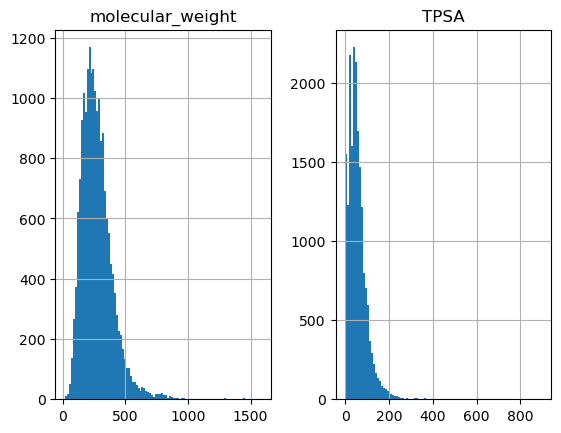

In [41]:
solute_list.hist(column=['molecular_weight', 'TPSA'], bins=100)

In [42]:
solute_list[['molecular_weight', 'TPSA']].describe()


,molecular_weight,TPSA
count,19217.000000,19217.000000
mean,274.740680,56.135425
std,127.149355,44.892349
min,20.006000,0.000000
25%,186.295000,26.300000
50%,255.484000,48.000000
75%,335.495000,74.430000
max,1583.582000,896.660000


In [43]:
def find_outlier(df, column):
    # Find first and third quartile
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    
    # Find interquartile range
    IQR = q3 - q1
    
    # Find lower and upper bound
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    
    # Remove outliers
    df[column] = df[column][df[column] > lower_bound]
    df[column] = df[column][df[column] < upper_bound]
    
    return df

In [44]:
solute_list = find_outlier(solute_list, 'molecular_weight')
solute_list = find_outlier(solute_list, 'TPSA')
solute_list

,InChIKey,solute_id,smiles_canon,molecular_weight,TPSA
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,solute_0,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,242.661,34.14
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,solute_1,NC(N)=NS(=O)(=O)c1ccc(N)cc1,214.250,124.56
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,solute_2,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,345.374,88.56
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,solute_3,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,235.239,69.44
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,solute_4,O=C1C=Cc2ccccc2C1=NO,173.171,49.66
...,...,...,...,...,...
19214,RFZHJHSNHYIRNE-UHFFFAOYSA-N,solute_19214,CCC(C)(O)C(C)C,116.204,20.23
19215,OWNAXTAAAQTBSP-UHFFFAOYSA-N,solute_19215,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,279.340,70.67
19216,RKUNBYITZUJHSG-UHFFFAOYSA-N,solute_19216,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,289.375,49.77
19217,DFBKLUNHFCTMDC-UHFFFAOYSA-N,solute_19217,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,380.913,12.53


In [45]:
solute_list = solute_list.dropna()
solute_list.isnull().any()

InChIKey            False
solute_id           False
smiles_canon        False
molecular_weight    False
TPSA                False
dtype: bool

In [46]:
solute_list = solute_list.reset_index(drop=True)
solute_list

,InChIKey,solute_id,smiles_canon,molecular_weight,TPSA
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,solute_0,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,242.661,34.14
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,solute_1,NC(N)=NS(=O)(=O)c1ccc(N)cc1,214.250,124.56
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,solute_2,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,345.374,88.56
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,solute_3,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,235.239,69.44
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,solute_4,O=C1C=Cc2ccccc2C1=NO,173.171,49.66
...,...,...,...,...,...
18250,RFZHJHSNHYIRNE-UHFFFAOYSA-N,solute_19214,CCC(C)(O)C(C)C,116.204,20.23
18251,OWNAXTAAAQTBSP-UHFFFAOYSA-N,solute_19215,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,279.340,70.67
18252,RKUNBYITZUJHSG-UHFFFAOYSA-N,solute_19216,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,289.375,49.77
18253,DFBKLUNHFCTMDC-UHFFFAOYSA-N,solute_19217,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,380.913,12.53


array([[<Axes: title={'center': 'molecular_weight'}>,
        <Axes: title={'center': 'TPSA'}>]], dtype=object)

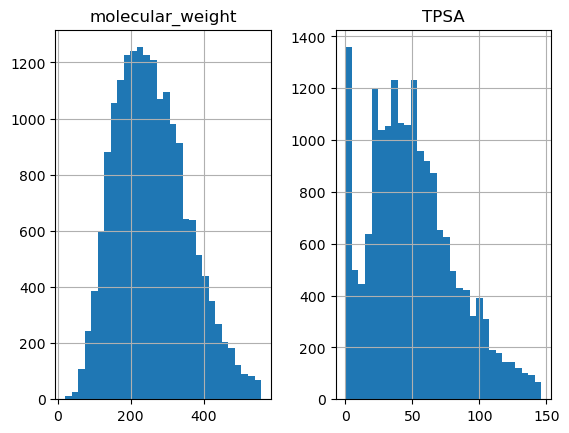

In [47]:
solute_list.hist(['molecular_weight','TPSA'], bins=30)

In [48]:
solute_list[['molecular_weight', 'TPSA']].describe()

,molecular_weight,TPSA
count,18255.000000,18255.000000
mean,258.740173,50.201566
std,99.307139,31.989978
min,20.006000,0.000000
25%,183.211000,26.300000
50%,249.266000,46.530000
75%,324.312500,69.560000
max,557.891000,146.340000


In [49]:
def set_polarity_classification(df, threshold=20):
    classification = []
    for tpsa in df['TPSA']:
        if tpsa>=threshold:
            classification.append('polar')
        else:
            classification.append('non-polar')
    df['polarity_class'] = classification

def set_size_classification(df, threshold=300):
    classification = []
    for weight in df['molecular_weight']:
        if weight>=threshold:
            classification.append('large')
        else:
            classification.append('small')
    df['size_class'] = classification

def set_hybrid_classification(df, categories):
    hybrid_class = []
    for i in range(len(df)):
        classification = [str(df.iloc[i][j]) for j in categories]
        classification = ','.join(classification)
        hybrid_class.append(classification)
    df['hybrid_class'] = hybrid_class

In [50]:
set_polarity_classification(solute_list)
set_polarity_classification(solvent_list)
set_size_classification(solute_list)
set_size_classification(solvent_list)
solute_list

,InChIKey,solute_id,smiles_canon,molecular_weight,TPSA,polarity_class,size_class
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,solute_0,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,242.661,34.14,polar,small
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,solute_1,NC(N)=NS(=O)(=O)c1ccc(N)cc1,214.250,124.56,polar,small
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,solute_2,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,345.374,88.56,polar,large
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,solute_3,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,235.239,69.44,polar,small
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,solute_4,O=C1C=Cc2ccccc2C1=NO,173.171,49.66,polar,small
...,...,...,...,...,...,...,...
18250,RFZHJHSNHYIRNE-UHFFFAOYSA-N,solute_19214,CCC(C)(O)C(C)C,116.204,20.23,polar,small
18251,OWNAXTAAAQTBSP-UHFFFAOYSA-N,solute_19215,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,279.340,70.67,polar,small
18252,RKUNBYITZUJHSG-UHFFFAOYSA-N,solute_19216,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,289.375,49.77,polar,small
18253,DFBKLUNHFCTMDC-UHFFFAOYSA-N,solute_19217,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,380.913,12.53,non-polar,large


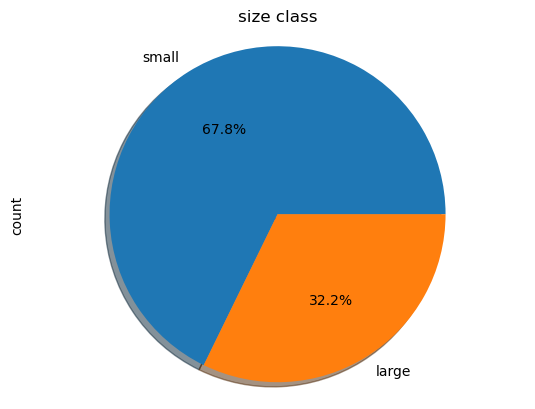

In [51]:
counts = solute_list['size_class'].value_counts()
counts.plot.pie(autopct='%1.1f%%', shadow=True)

plt.title('size class')
plt.axis('equal')
plt.show()

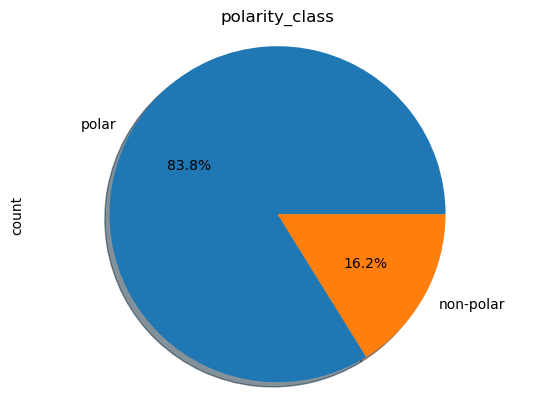

In [52]:
counts = solute_list['polarity_class'].value_counts()
counts.plot.pie(autopct='%1.1f%%', shadow=True)

plt.title('polarity_class')
plt.axis('equal')
plt.show()

In [53]:
categories = ['polarity_class', 'size_class']
set_hybrid_classification(solute_list, categories)
set_hybrid_classification(solvent_list, categories)
solute_list

,InChIKey,solute_id,smiles_canon,molecular_weight,TPSA,polarity_class,size_class,hybrid_class
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,solute_0,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,242.661,34.14,polar,small,"polar,small"
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,solute_1,NC(N)=NS(=O)(=O)c1ccc(N)cc1,214.250,124.56,polar,small,"polar,small"
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,solute_2,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,345.374,88.56,polar,large,"polar,large"
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,solute_3,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,235.239,69.44,polar,small,"polar,small"
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,solute_4,O=C1C=Cc2ccccc2C1=NO,173.171,49.66,polar,small,"polar,small"
...,...,...,...,...,...,...,...,...
18250,RFZHJHSNHYIRNE-UHFFFAOYSA-N,solute_19214,CCC(C)(O)C(C)C,116.204,20.23,polar,small,"polar,small"
18251,OWNAXTAAAQTBSP-UHFFFAOYSA-N,solute_19215,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,279.340,70.67,polar,small,"polar,small"
18252,RKUNBYITZUJHSG-UHFFFAOYSA-N,solute_19216,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,289.375,49.77,polar,small,"polar,small"
18253,DFBKLUNHFCTMDC-UHFFFAOYSA-N,solute_19217,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,380.913,12.53,non-polar,large,"non-polar,large"


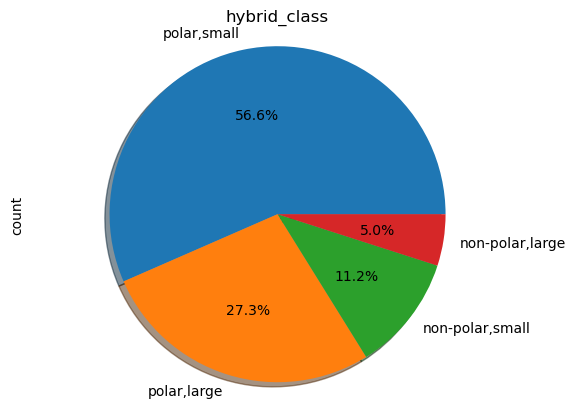

In [54]:
counts = solute_list['hybrid_class'].value_counts()
counts.plot.pie(autopct='%1.1f%%', shadow=True)

plt.title('hybrid_class')
plt.axis('equal')
plt.show()

In [55]:
solvent_list

,solvent_name,solvent_id,smiles_canon,molecular_weight,TPSA,polarity_class,size_class,hybrid_class
0,WATER,solvent_844,O,18.015,31.5,polar,small,"polar,small"


In [56]:
solute_list.to_csv('../data/solubility_water/solute_list_with_polarity_and_size.csv', index=False)
solvent_list.to_csv('../data/solubility_water/solvent_list_water_with_polarity_and_size.csv', index=False)

In [104]:
train_set = pd.read_csv('..\data\solubility_water\COMPATIBLE_unique_train_water_final.csv')
test_set = pd.read_csv('..\data\solubility_water\COMPATIBLE_unique_test_water_final.csv')
solute_list = pd.read_csv('..\data\solubility_water\solute_list_with_polarity_and_size.csv', index_col='solute_id')
solvent_list = pd.read_csv('..\data\solubility_water\solvent_list_water_with_polarity_and_size.csv', index_col='solvent_id')
solute_list

,InChIKey,smiles_canon,molecular_weight,TPSA,polarity_class,size_class,hybrid_class
solute_id,,,,,,,
solute_0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,242.661,34.14,polar,small,"polar,small"
solute_1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,NC(N)=NS(=O)(=O)c1ccc(N)cc1,214.250,124.56,polar,small,"polar,small"
solute_2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,345.374,88.56,polar,large,"polar,large"
solute_3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,235.239,69.44,polar,small,"polar,small"
solute_4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,O=C1C=Cc2ccccc2C1=NO,173.171,49.66,polar,small,"polar,small"
...,...,...,...,...,...,...,...
solute_19214,RFZHJHSNHYIRNE-UHFFFAOYSA-N,CCC(C)(O)C(C)C,116.204,20.23,polar,small,"polar,small"
solute_19215,OWNAXTAAAQTBSP-UHFFFAOYSA-N,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,279.340,70.67,polar,small,"polar,small"
solute_19216,RKUNBYITZUJHSG-UHFFFAOYSA-N,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,289.375,49.77,polar,small,"polar,small"


In [105]:
train_set

,InChIKey,smiles_canon,LogS,occurence,solvent_id,solute_id
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,-5.540000,1.0,solvent_844,solute_0
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,NC(N)=NS(=O)(=O)c1ccc(N)cc1,-1.984970,1.0,solvent_844,solute_1
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,-3.912000,1.0,solvent_844,solute_2
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,-3.656000,1.0,solvent_844,solute_3
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,O=C1C=Cc2ccccc2C1=NO,-2.937000,1.0,solvent_844,solute_4
...,...,...,...,...,...,...
17930,CTAPFRYPJLPFDF-UHFFFAOYSA-N,c1cnoc1,0.383095,2.0,solvent_844,solute_17932
17931,UYJUZNLFJAWNEZ-UHFFFAOYSA-N,c1coc(-c2nc3ccccc3[nH]2)c1,-3.414016,2.0,solvent_844,solute_17933
17932,NSPMIYGKQJPBQR-UHFFFAOYSA-N,c1nc[nH]n1,0.897170,2.0,solvent_844,solute_17934
17933,KDCGOANMDULRCW-UHFFFAOYSA-N,c1ncc2[nH]cnc2n1,0.619695,2.0,solvent_844,solute_17935


In [106]:
def add_hybridclass_to_binary_mixtures(df, solute_df, solvent_df):
    hybrid_class = []
    for i in range(len(df)):
        solute_id = df.iloc[i]['solute_id']
        solvent_id = df.iloc[i]['solvent_id']
        try:
            solute_hybrid_class = solute_df.loc[solute_id]['hybrid_class']
            solvent_hybrid_class = solvent_df.loc[solvent_id]['hybrid_class']
        except:
            solute_hybrid_class = None
        hybrid_class += [solute_hybrid_class]
    df['hybrid_class'] = hybrid_class


In [107]:
add_hybridclass_to_binary_mixtures(train_set, solute_list, solvent_list)
train_set

,InChIKey,smiles_canon,LogS,occurence,solvent_id,solute_id,hybrid_class
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,-5.540000,1.0,solvent_844,solute_0,"polar,small"
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,NC(N)=NS(=O)(=O)c1ccc(N)cc1,-1.984970,1.0,solvent_844,solute_1,"polar,small"
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,-3.912000,1.0,solvent_844,solute_2,"polar,large"
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,-3.656000,1.0,solvent_844,solute_3,"polar,small"
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,O=C1C=Cc2ccccc2C1=NO,-2.937000,1.0,solvent_844,solute_4,"polar,small"
...,...,...,...,...,...,...,...
17930,CTAPFRYPJLPFDF-UHFFFAOYSA-N,c1cnoc1,0.383095,2.0,solvent_844,solute_17932,"polar,small"
17931,UYJUZNLFJAWNEZ-UHFFFAOYSA-N,c1coc(-c2nc3ccccc3[nH]2)c1,-3.414016,2.0,solvent_844,solute_17933,"polar,small"
17932,NSPMIYGKQJPBQR-UHFFFAOYSA-N,c1nc[nH]n1,0.897170,2.0,solvent_844,solute_17934,"polar,small"
17933,KDCGOANMDULRCW-UHFFFAOYSA-N,c1ncc2[nH]cnc2n1,0.619695,2.0,solvent_844,solute_17935,"polar,small"


In [108]:
train_set = train_set.dropna()
train_set = train_set.reset_index(drop=False)
colnames = train_set.columns
train_set = train_set[colnames[1:]]
train_set
    

,InChIKey,smiles_canon,LogS,occurence,solvent_id,solute_id,hybrid_class
0,BOCJQSFSGAZAPQ-UHFFFAOYSA-N,O=C1c2ccccc2C(=O)c2c(Cl)cccc21,-5.540000,1.0,solvent_844,solute_0,"polar,small"
1,BRBKOPJOKNSWSG-UHFFFAOYSA-N,NC(N)=NS(=O)(=O)c1ccc(N)cc1,-1.984970,1.0,solvent_844,solute_1,"polar,small"
2,BRPOVUNVTUCYNN-UHFFFAOYSA-N,CCC1C(N)CN1c1cc2c(cc1F)c(=O)c(C(=O)O)cn2C1CC1,-3.912000,1.0,solvent_844,solute_2,"polar,large"
3,BWXSXZAIQQSFPW-UHFFFAOYSA-N,CCC1(CC)OC(=O)c2cc([N+](=O)[O-])ccc21,-3.656000,1.0,solvent_844,solute_3,"polar,small"
4,CAQHPYSDQFDJAL-UHFFFAOYSA-N,O=C1C=Cc2ccccc2C1=NO,-2.937000,1.0,solvent_844,solute_4,"polar,small"
...,...,...,...,...,...,...,...
16980,CTAPFRYPJLPFDF-UHFFFAOYSA-N,c1cnoc1,0.383095,2.0,solvent_844,solute_17932,"polar,small"
16981,UYJUZNLFJAWNEZ-UHFFFAOYSA-N,c1coc(-c2nc3ccccc3[nH]2)c1,-3.414016,2.0,solvent_844,solute_17933,"polar,small"
16982,NSPMIYGKQJPBQR-UHFFFAOYSA-N,c1nc[nH]n1,0.897170,2.0,solvent_844,solute_17934,"polar,small"
16983,KDCGOANMDULRCW-UHFFFAOYSA-N,c1ncc2[nH]cnc2n1,0.619695,2.0,solvent_844,solute_17935,"polar,small"


In [109]:
add_hybridclass_to_binary_mixtures(test_set, solute_list, solvent_list)
test_set = test_set.dropna()
test_set = test_set.reset_index(drop=False)
colnames = test_set.columns
test_set = test_set[colnames[1:]]
test_set

,InChIKey,smiles_canon,LogS,occurence,solvent_id,solute_id,hybrid_class
0,OFBQJSOFQDEBGM-UHFFFAOYSA-N,CCCCC,-3.180,1.0,solvent_844,solute_17937,"non-polar,small"
1,RGSFGYAAUTVSQA-UHFFFAOYSA-N,C1CCCC1,-2.640,1.0,solvent_844,solute_17938,"non-polar,small"
2,VLKZOEOYAKHREP-UHFFFAOYSA-N,CCCCCC,-3.840,1.0,solvent_844,solute_17939,"non-polar,small"
3,AFABGHUZZDYHJO-UHFFFAOYSA-N,CCCC(C)C,-3.740,1.0,solvent_844,solute_17940,"non-polar,small"
4,HNRMPXKDFBEGFZ-UHFFFAOYSA-N,CCC(C)(C)C,-3.550,1.0,solvent_844,solute_17941,"non-polar,small"
...,...,...,...,...,...,...,...
1265,RFZHJHSNHYIRNE-UHFFFAOYSA-N,CCC(C)(O)C(C)C,-1.035,2.0,solvent_844,solute_19214,"polar,small"
1266,OWNAXTAAAQTBSP-UHFFFAOYSA-N,CN(C)C(=O)Nc1cccc(OC(=O)NC(C)(C)C)c1,-2.930,2.0,solvent_844,solute_19215,"polar,small"
1267,RKUNBYITZUJHSG-UHFFFAOYSA-N,CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,-2.015,2.0,solvent_844,solute_19216,"polar,small"
1268,DFBKLUNHFCTMDC-UHFFFAOYSA-N,ClC1=C(Cl)C2(Cl)C3C4CC(C5OC45)C3C1(Cl)C2(Cl)Cl,-6.235,2.0,solvent_844,solute_19217,"non-polar,large"


In [110]:
train_set.to_csv('../data/solubility_water/COMPATIBLE_unique_train_water_with_hybrid_classes.csv', index=False)
test_set.to_csv('../data/solubility_water/COMPATIBLE_unique_test_water_with_hybrid_classes.csv', index=False)